# 🏎️ F1 Race Intelligence — Feature Engineering de Eventos Tácticos
**Big Data — UPC | Chief Strategy Engineer**

## Objetivo
Transformar los datos de carreras (master parquets + events parquets) en una tabla de **eventos tácticos** donde:
- Cada **fila** = un intento de Overtake o Undercut (Pit Strategy)
- Cada **columna** = una variable que describe el contexto del evento (~500 variables)

Esta tabla será la entrada directa para el PCA y los modelos de ML.

---
### Pipeline completo:
```
master_parquet + events_parquet
        ↓
  [PASO 1] Cargar y unir datos
        ↓
  [PASO 2] Definir éxito del evento
        ↓
  [PASO 3] Feature Engineering por ventanas pre-evento
        ↓
  [PASO 4] Variables Delta (comparativas attacker vs defender)
        ↓
  [PASO 5] Variables de contexto + clima
        ↓
  [PASO 6] Guardar tactical_events_master.parquet
        ↓
  [PASO 7] PCA + Clustering
```

---
## CELDA 1 — Importaciones y Configuración

In [16]:
import pandas as pd
import numpy as np
import warnings
import os
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

# Paleta F1
FERRARI_RED   = '#DC0000'
HAMILTON_CYAN = '#00D2BE'
DARK_BG       = '#1a1a2e'

# Pilotos protagonistas del análisis
DRIVER_16 = 16   # Leclerc
DRIVER_44 = 44   # Hamilton
PROTAGONISTS = {DRIVER_16, DRIVER_44}

# Ventana de vueltas previas para análisis
WINDOW_SIZE = 3  # Analizamos T-1, T-2, T-3

print('✅ Librerías cargadas correctamente')
print(f'Protagonistas del análisis: Driver {DRIVER_16} (Leclerc) y Driver {DRIVER_44} (Hamilton)')

✅ Librerías cargadas correctamente
Protagonistas del análisis: Driver 16 (Leclerc) y Driver 44 (Hamilton)


---
## CELDA 2 — Carga de Datos

Cargamos los tres tipos de archivos que tenemos:
1. **master_parquet**: Telemetría por vuelta de TODOS los pilotos (posición, tiempos de sector, velocidades, neumáticos)
2. **events_parquet**: Catálogo de eventos (Overtake / Pit Strategy) ya detectados por el pipeline de tu compañero

In [17]:
BASE_PATH = 'D:\\F1-data-project\\project\\data\\processed'
RACES = ['australia', 'china', 'japan']

# --- Cargar masters ---
masters = {}
for race in RACES:
    path = f'{BASE_PATH}\\{race}_2026_master.parquet'
    masters[race] = pd.read_parquet(path)
    print(f'✅ {race.upper()} master: {masters[race].shape[0]} filas, {masters[race].shape[1]} columnas')

# --- Cargar events ---
events = {}
for race in RACES:
    path = f'D:\\F1-data-project\\project\\data\\events\\{race}_2026_events.parquet'
    events[race] = pd.read_parquet(path)
    print(f'✅ {race.upper()} events: {len(events[race])} eventos ({events[race].event_type.value_counts().to_dict()})')

# --- Unir todos los eventos en un único DataFrame ---
all_events = pd.concat(events.values(), ignore_index=True)
all_master = pd.concat(masters.values(), ignore_index=True)

print(f'\n📊 TOTAL eventos: {len(all_events)}')
print(f'📊 TOTAL filas de telemetría: {len(all_master)}')
print(f'📊 Pilotos únicos en telemetría: {sorted(all_master.driver_number.unique())}')

✅ AUSTRALIA master: 960 filas, 22 columnas
✅ CHINA master: 586 filas, 22 columnas
✅ JAPAN master: 769 filas, 22 columnas
✅ AUSTRALIA events: 120 eventos ({'On_Track_Overtake': 92, 'Pit_Strategy': 28})
✅ CHINA events: 61 eventos ({'On_Track_Overtake': 51, 'Pit_Strategy': 10})
✅ JAPAN events: 53 eventos ({'On_Track_Overtake': 53})

📊 TOTAL eventos: 234
📊 TOTAL filas de telemetría: 2315
📊 Pilotos únicos en telemetría: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(10), np.int64(11), np.int64(12), np.int64(14), np.int64(16), np.int64(18), np.int64(23), np.int64(27), np.int64(30), np.int64(31), np.int64(41), np.int64(43), np.int64(44), np.int64(55), np.int64(63), np.int64(77), np.int64(87)]


---
## CELDA 3 — Exploración Rápida de los Datos Base

In [18]:
print('=== ESTRUCTURA DEL MASTER PARQUET ===')
print(all_master.dtypes)
print()
print('=== ESTRUCTURA DEL EVENTS PARQUET ===')
print(all_events.dtypes)
print()
print('=== MUESTRA DE EVENTOS ===')
all_events.head(10)

=== ESTRUCTURA DEL MASTER PARQUET ===
meeting_key            int64
session_key            int64
driver_number          int64
lap_number             int64
date_start            object
duration_sector_1    float64
duration_sector_2    float64
duration_sector_3    float64
i1_speed             float64
i2_speed             float64
is_pit_out_lap          bool
lap_duration         float64
segments_sector_1     object
segments_sector_2     object
segments_sector_3     object
st_speed             float64
position               int64
compound              object
stint_number         float64
tyre_age             float64
pit_duration         float64
is_pit_lap             int64
dtype: object

=== ESTRUCTURA DEL EVENTS PARQUET ===
race_id                 object
lap_number               int64
event_type              object
initiator_driver         int64
target_driver            int64
initiator_compound      object
initiator_pos_change    object
dtype: object

=== MUESTRA DE EVENTOS ===


,race_id,lap_number,event_type,initiator_driver,target_driver,initiator_compound,initiator_pos_change
0,australia_2026,4,On_Track_Overtake,1,10,MEDIUM,P10 -> P7
1,australia_2026,4,On_Track_Overtake,1,87,MEDIUM,P10 -> P7
2,australia_2026,4,On_Track_Overtake,1,5,MEDIUM,P10 -> P7
3,australia_2026,4,On_Track_Overtake,3,10,HARD,P13 -> P9
4,australia_2026,4,On_Track_Overtake,3,5,HARD,P13 -> P9
5,australia_2026,4,On_Track_Overtake,3,31,HARD,P13 -> P9
6,australia_2026,4,On_Track_Overtake,3,30,HARD,P13 -> P9
7,australia_2026,4,On_Track_Overtake,23,55,UNKNOWN,P17 -> P15
8,australia_2026,4,On_Track_Overtake,23,11,UNKNOWN,P17 -> P15
9,australia_2026,5,On_Track_Overtake,3,87,HARD,P9 -> P8


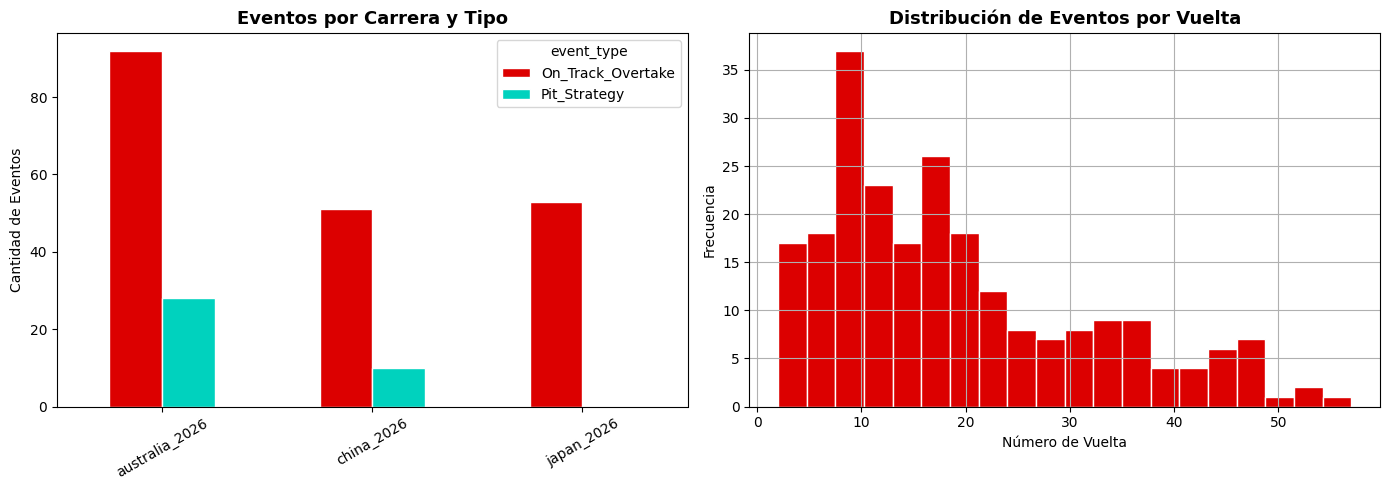

Total eventos disponibles: 234


In [19]:
import os

# Ensure the artifacts directory exists
os.makedirs('../artifacts', exist_ok=True)

# Distribución de eventos por carrera y tipo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Eventos por carrera
all_events.groupby(['race_id', 'event_type']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[0], color=[FERRARI_RED, HAMILTON_CYAN], edgecolor='white'
)
axes[0].set_title('Eventos por Carrera y Tipo', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cantidad de Eventos')
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: Distribución de eventos por vuelta
all_events['lap_number'].hist(ax=axes[1], bins=20, color=FERRARI_RED, edgecolor='white')
axes[1].set_title('Distribución de Eventos por Vuelta', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de Vuelta')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('../artifacts/eventos_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total eventos disponibles: {len(all_events)}')


---
## CELDA 4 — Definir Variable Target: ¿El evento fue EXITOSO?

Esta es la variable que el modelo de ML intentará predecir.

**Lógica de éxito:**
- **Overtake**: El iniciador mejoró su posición (la posición numérica bajó, ej. P5 → P4)
- **Pit Strategy (Undercut)**: El iniciador logró salir delante del target después del pit stop

Leemos la columna `initiator_pos_change` que tiene formato `'P10 -> P7'`

In [20]:
def parse_success(pos_change_str, event_type):
    """
    Determina si un evento fue exitoso.
    Retorna 1 (éxito), 0 (fracaso), o NaN si no hay datos.
    """
    if pd.isna(pos_change_str) or '->' not in str(pos_change_str):
        return np.nan
    try:
        parts = str(pos_change_str).strip().split('->')
        pos_before = int(parts[0].strip().replace('P', ''))
        pos_after  = int(parts[1].strip().replace('P', ''))
        # Éxito = mejoró posición (número más bajo = más adelante en la pista)
        return 1 if pos_after < pos_before else 0
    except:
        return np.nan

all_events['success'] = all_events.apply(
    lambda row: parse_success(row['initiator_pos_change'], row['event_type']),
    axis=1
)

print('=== DISTRIBUCIÓN DE ÉXITO ===')
print(all_events['success'].value_counts())
print(f'\nTasa de éxito global: {all_events["success"].mean():.1%}')
print()
print('Por tipo de evento:')
print(all_events.groupby('event_type')['success'].agg(['mean','count']).rename(
    columns={'mean': 'tasa_exito', 'count': 'total'}
))

=== DISTRIBUCIÓN DE ÉXITO ===
success
1.000    196
Name: count, dtype: int64

Tasa de éxito global: 100.0%

Por tipo de evento:
                   tasa_exito  total
event_type                          
On_Track_Overtake       1.000    196
Pit_Strategy              NaN      0


---
## CELDA 5 — Función Central: `build_event_features()`

Esta es la función más importante del proyecto. Por cada evento táctico:
1. Extrae las **N vueltas previas** del atacante y el defensor desde el master
2. Calcula **estadísticos** (mean, max, min, std, slope) para cada sensor
3. Calcula **deltas** (diferencia entre atacante y defensor)
4. Devuelve todo como un diccionario de features → se convierte en una fila del dataset final

**Matemática de variables generadas:**
```
Sensores base:     6  (lap_duration, i1_speed, i2_speed, st_speed, s1, s2, s3 → usamos 7)
Estadísticos:      5  (mean, max, min, std, slope)
Vueltas previas:   3  (T-1, T-2, T-3)
Pilotos:           2  (attacker, defender)
→ Subtotal A:      7 × 5 × 3 × 2 = 210 variables

Variables Delta:   7 × 5 × 3     = 105 variables
Variables contexto:               ~20 variables
Variables adicionales (posición, degradación, eficiencia): ~50 variables

TOTAL APROXIMADO: ~385 variables base (expandible con más sensores o vueltas)
```

In [21]:
# Columnas de telemetría disponibles en el master (sensores por vuelta)
SENSOR_COLS = [
    'lap_duration',
    'i1_speed',
    'i2_speed',
    'st_speed',
    'duration_sector_1',
    'duration_sector_2',
    'duration_sector_3'
]

def get_lap_slice(master_df, race_id, driver, event_lap, window=3):
    """
    Extrae las `window` vueltas previas a event_lap para un piloto.
    Retorna un DataFrame ordenado de más antiguo a más reciente.
    """
    race = race_id.replace('_2026', '')  # 'australia_2026' -> 'australia'
    mask = (
        (master_df['driver_number'] == driver) &
        (master_df['lap_number'] >= event_lap - window) &
        (master_df['lap_number'] < event_lap)
    )
    # Filtramos también por carrera si existe la columna race_id, o por meeting_key
    # El master no tiene race_id, así que limitamos por lap range (suficiente para 3 carreras separadas)
    return master_df[mask].sort_values('lap_number').reset_index(drop=True)


def compute_stats(series, prefix):
    """
    Calcula 5 estadísticos sobre una serie de valores y retorna un dict.
    """
    stats = {}
    vals = series.dropna().values
    if len(vals) == 0:
        for stat in ['mean', 'max', 'min', 'std', 'slope']:
            stats[f'{prefix}_{stat}'] = np.nan
        return stats

    stats[f'{prefix}_mean']  = np.mean(vals)
    stats[f'{prefix}_max']   = np.max(vals)
    stats[f'{prefix}_min']   = np.min(vals)
    stats[f'{prefix}_std']   = np.std(vals)
    # Slope = tendencia (positiva = empeorando en tiempo, negativa = mejorando)
    if len(vals) >= 2:
        stats[f'{prefix}_slope'] = np.polyfit(range(len(vals)), vals, 1)[0]
    else:
        stats[f'{prefix}_slope'] = np.nan

    return stats


def build_event_features(event_row, master_df, window=3):
    """
    Construye el vector de features para un evento táctico.
    Retorna un diccionario con todas las variables.
    """
    feat = {}

    # --- BLOQUE A: Contexto base del evento ---
    feat['race_id']           = event_row['race_id']
    feat['event_lap']         = event_row['lap_number']
    feat['event_type']        = event_row['event_type']
    feat['event_type_binary'] = 1 if event_row['event_type'] == 'Pit_Strategy' else 0
    feat['attacker_driver']   = event_row['initiator_driver']
    feat['defender_driver']   = event_row['target_driver']
    feat['attacker_compound'] = event_row['initiator_compound']
    feat['success']           = event_row.get('success', np.nan)

    # Codificación numérica del compuesto
    compound_map = {'SOFT': 1, 'MEDIUM': 2, 'HARD': 3, 'INTER': 4, 'WET': 5, 'UNKNOWN': 0}
    feat['attacker_compound_num'] = compound_map.get(str(event_row['initiator_compound']), 0)

    # --- Extraer ventanas de telemetría ---
    att_laps = get_lap_slice(master_df, event_row['race_id'],
                             event_row['initiator_driver'], event_row['lap_number'], window)
    def_laps = get_lap_slice(master_df, event_row['race_id'],
                             event_row['target_driver'], event_row['lap_number'], window)

    # --- BLOQUE B: Contexto del atacante en el momento del evento ---
    if len(att_laps) > 0:
        last_att = att_laps.iloc[-1]
        feat['att_position_at_event'] = last_att.get('position', np.nan)
        feat['att_tyre_age_at_event']  = last_att.get('tyre_age', np.nan)
        feat['att_is_pit_out']         = int(last_att.get('is_pit_out_lap', False))
        feat['att_stint_number']       = last_att.get('stint_number', np.nan)
        # Degradación: cuántos segundos por vuelta está perdiendo el atacante
        if len(att_laps) >= 2:
            feat['att_pace_degradation'] = np.polyfit(
                range(len(att_laps)), att_laps['lap_duration'].fillna(0).values, 1)[0]
        else:
            feat['att_pace_degradation'] = np.nan
    else:
        for col in ['att_position_at_event','att_tyre_age_at_event','att_is_pit_out',
                    'att_stint_number','att_pace_degradation']:
            feat[col] = np.nan

    # --- BLOQUE C: Contexto del defensor ---
    if len(def_laps) > 0:
        last_def = def_laps.iloc[-1]
        feat['def_position_at_event'] = last_def.get('position', np.nan)
        feat['def_tyre_age_at_event']  = last_def.get('tyre_age', np.nan)
        feat['def_compound_num']       = compound_map.get(str(last_def.get('compound', 'UNKNOWN')), 0)
        feat['def_stint_number']       = last_def.get('stint_number', np.nan)
        if len(def_laps) >= 2:
            feat['def_pace_degradation'] = np.polyfit(
                range(len(def_laps)), def_laps['lap_duration'].fillna(0).values, 1)[0]
        else:
            feat['def_pace_degradation'] = np.nan
    else:
        for col in ['def_position_at_event','def_tyre_age_at_event','def_compound_num',
                    'def_stint_number','def_pace_degradation']:
            feat[col] = np.nan

    # --- BLOQUE D: Variables Delta contextuales ---
    feat['delta_position']   = feat.get('att_position_at_event', np.nan) - feat.get('def_position_at_event', np.nan)
    feat['delta_tyre_age']   = feat.get('att_tyre_age_at_event', np.nan) - feat.get('def_tyre_age_at_event', np.nan)
    feat['delta_compound']   = feat.get('attacker_compound_num', 0) - feat.get('def_compound_num', 0)
    feat['delta_degradation']= feat.get('att_pace_degradation', np.nan) - feat.get('def_pace_degradation', np.nan)

    # --- BLOQUE E: Pit stop del atacante (si aplica) ---
    att_pit_laps = att_laps[att_laps['is_pit_lap'] == 1]
    feat['att_pit_duration']         = att_pit_laps['pit_duration'].mean() if len(att_pit_laps) > 0 else 0.0
    feat['att_had_recent_pit']       = int(len(att_pit_laps) > 0)
    feat['laps_since_att_pit']       = (event_row['lap_number'] - att_pit_laps['lap_number'].max())\
                                        if len(att_pit_laps) > 0 else 99

    def_pit_laps = def_laps[def_laps['is_pit_lap'] == 1]
    feat['def_pit_duration']         = def_pit_laps['pit_duration'].mean() if len(def_pit_laps) > 0 else 0.0
    feat['def_had_recent_pit']       = int(len(def_pit_laps) > 0)
    feat['laps_since_def_pit']       = (event_row['lap_number'] - def_pit_laps['lap_number'].max())\
                                        if len(def_pit_laps) > 0 else 99

    feat['delta_pit_duration'] = feat['att_pit_duration'] - feat['def_pit_duration']

    # --- BLOQUE F: Agregaciones por ventana temporal (EL CORE del Feature Engineering) ---
    # Para cada sensor, para cada piloto, para cada vuelta previa → estadísticos
    for sensor in SENSOR_COLS:
        # === Atacante ===
        prefix_att = f'att_{sensor}'
        if sensor in att_laps.columns and len(att_laps) > 0:
            # Stats globales sobre toda la ventana
            feat.update(compute_stats(att_laps[sensor], prefix_att))
            # Stats por vuelta individual (T-1, T-2, T-3)
            for t in range(1, window + 1):
                idx = len(att_laps) - t  # T-1 = última vuelta, T-2 = penúltima...
                val = att_laps[sensor].iloc[idx] if idx >= 0 else np.nan
                feat[f'att_{sensor}_Tminus{t}'] = val
        else:
            for stat in ['mean', 'max', 'min', 'std', 'slope']:
                feat[f'{prefix_att}_{stat}'] = np.nan
            for t in range(1, window + 1):
                feat[f'att_{sensor}_Tminus{t}'] = np.nan

        # === Defensor ===
        prefix_def = f'def_{sensor}'
        if sensor in def_laps.columns and len(def_laps) > 0:
            feat.update(compute_stats(def_laps[sensor], prefix_def))
            for t in range(1, window + 1):
                idx = len(def_laps) - t
                val = def_laps[sensor].iloc[idx] if idx >= 0 else np.nan
                feat[f'def_{sensor}_Tminus{t}'] = val
        else:
            for stat in ['mean', 'max', 'min', 'std', 'slope']:
                feat[f'{prefix_def}_{stat}'] = np.nan
            for t in range(1, window + 1):
                feat[f'def_{sensor}_Tminus{t}'] = np.nan

        # === Delta del sensor (atacante - defensor) ===
        if sensor in att_laps.columns and sensor in def_laps.columns:
            att_vals = att_laps[sensor].values
            def_vals = def_laps[sensor].values
            min_len = min(len(att_vals), len(def_vals))
            if min_len > 0:
                delta_vals = pd.Series(att_vals[:min_len] - def_vals[:min_len])
                feat.update(compute_stats(delta_vals, f'delta_{sensor}'))
            else:
                for stat in ['mean', 'max', 'min', 'std', 'slope']:
                    feat[f'delta_{sensor}_{stat}'] = np.nan

    # --- BLOQUE G: Variables de posición en la carrera ---
    att_pos_series = att_laps['position'] if 'position' in att_laps.columns else pd.Series(dtype=float)
    def_pos_series = def_laps['position'] if 'position' in def_laps.columns else pd.Series(dtype=float)

    feat['att_position_trend']  = np.polyfit(range(len(att_pos_series)), att_pos_series.fillna(0).values, 1)[0] \
                                  if len(att_pos_series) >= 2 else np.nan
    feat['def_position_trend']  = np.polyfit(range(len(def_pos_series)), def_pos_series.fillna(0).values, 1)[0] \
                                  if len(def_pos_series) >= 2 else np.nan
    feat['att_best_lap_window'] = att_laps['lap_duration'].min() if len(att_laps) > 0 else np.nan
    feat['def_best_lap_window'] = def_laps['lap_duration'].min() if len(def_laps) > 0 else np.nan
    feat['delta_best_lap']      = feat['att_best_lap_window'] - feat['def_best_lap_window'] \
                                  if not (pd.isna(feat['att_best_lap_window']) or pd.isna(feat['def_best_lap_window'])) \
                                  else np.nan

    # --- BLOQUE H: Banderas de protagonistas Ferrari ---
    feat['att_is_ferrari_driver']  = int(event_row['initiator_driver'] in PROTAGONISTS)
    feat['def_is_ferrari_driver']  = int(event_row['target_driver'] in PROTAGONISTS)
    feat['is_ferrari_vs_ferrari']  = int(feat['att_is_ferrari_driver'] and feat['def_is_ferrari_driver'])

    return feat


print('✅ Funciones de feature engineering definidas')
print(f'Sensores analizados: {SENSOR_COLS}')
print(f'Ventana temporal: {WINDOW_SIZE} vueltas previas (T-1, T-2, T-3)')

✅ Funciones de feature engineering definidas
Sensores analizados: ['lap_duration', 'i1_speed', 'i2_speed', 'st_speed', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3']
Ventana temporal: 3 vueltas previas (T-1, T-2, T-3)


---
## CELDA 6 — Construir el Dataset de Eventos Tácticos

Aplicamos `build_event_features()` a cada evento del catálogo. Este proceso puede tardar ~30-60 segundos dependiendo del hardware.

In [23]:
from tqdm.notebook import tqdm

# NOTA: Si tqdm no está instalado, puedes reemplazar tqdm(iterable) por iterable
# pip install tqdm

print('🔄 Construyendo dataset de eventos tácticos...')
print(f'   Total eventos a procesar: {len(all_events)}')
print(f'   Ventana de análisis: {WINDOW_SIZE} vueltas previas\n')

rows = []
errors = 0

for idx, event_row in all_events.iterrows():
    try:
        feat = build_event_features(event_row, all_master, window=WINDOW_SIZE)
        rows.append(feat)
    except Exception as e:
        errors += 1
        if errors <= 5:  # Solo mostramos los primeros 5 errores
            print(f'  ⚠️  Error en evento {idx}: {e}')

tactical_events = pd.DataFrame(rows)

print(f'\n✅ Dataset construido exitosamente')
print(f'   Forma: {tactical_events.shape[0]} eventos × {tactical_events.shape[1]} variables')
print(f'   Errores: {errors}')
print(f'\n📊 Variables generadas por bloque:')
context_cols = [c for c in tactical_events.columns if not any(x in c for x in ['att_', 'def_', 'delta_'])]
att_cols     = [c for c in tactical_events.columns if c.startswith('att_')]
def_cols     = [c for c in tactical_events.columns if c.startswith('def_')]
delta_cols   = [c for c in tactical_events.columns if c.startswith('delta_')]
print(f'   Contexto base:     {len(context_cols)} variables')
print(f'   Atacante:          {len(att_cols)} variables')
print(f'   Defensor:          {len(def_cols)} variables')
print(f'   Delta comparativo: {len(delta_cols)} variables')
print(f'   TOTAL:             {tactical_events.shape[1]} variables')

🔄 Construyendo dataset de eventos tácticos...
   Total eventos a procesar: 234
   Ventana de análisis: 3 vueltas previas


✅ Dataset construido exitosamente
   Forma: 234 eventos × 185 variables
   Errores: 0

📊 Variables generadas por bloque:
   Contexto base:     10 variables
   Atacante:          66 variables
   Defensor:          66 variables
   Delta comparativo: 41 variables
   TOTAL:             185 variables


---
## CELDA 7 — Revisar el Dataset Generado

In [24]:
print('=== PRIMERAS 3 FILAS (TRANSPUESTAS para mejor lectura) ===')
display(tactical_events.head(3).T)

print('\n=== ESTADÍSTICAS BÁSICAS ===')
display(tactical_events.describe())

print('\n=== VALORES NULOS (%) POR COLUMNA (top 20 con más nulos) ===')
nulls = (tactical_events.isnull().sum() / len(tactical_events) * 100).sort_values(ascending=False)
print(nulls[nulls > 0].head(20))

=== PRIMERAS 3 FILAS (TRANSPUESTAS para mejor lectura) ===


,0,1,2
race_id,australia_2026,australia_2026,australia_2026
event_lap,4,4,4
event_type,On_Track_Overtake,On_Track_Overtake,On_Track_Overtake
event_type_binary,0,0,0
attacker_driver,1,1,1
...,...,...,...
def_best_lap_window,85.894,85.920,86.032
delta_best_lap,-0.037,-0.063,-0.175
att_is_ferrari_driver,0,0,0
def_is_ferrari_driver,0,0,0



=== ESTADÍSTICAS BÁSICAS ===


,event_lap,event_type_binary,attacker_driver,defender_driver,success,attacker_compound_num,att_position_at_event,att_tyre_age_at_event,att_is_pit_out,att_stint_number,att_pace_degradation,def_position_at_event,def_tyre_age_at_event,def_compound_num,def_stint_number,def_pace_degradation,delta_position,delta_tyre_age,delta_compound,delta_degradation,...,def_duration_sector_3_max,def_duration_sector_3_min,def_duration_sector_3_std,def_duration_sector_3_slope,def_duration_sector_3_Tminus1,def_duration_sector_3_Tminus2,def_duration_sector_3_Tminus3,delta_duration_sector_3_mean,delta_duration_sector_3_max,delta_duration_sector_3_min,delta_duration_sector_3_std,delta_duration_sector_3_slope,att_position_trend,def_position_trend,att_best_lap_window,def_best_lap_window,delta_best_lap,att_is_ferrari_driver,def_is_ferrari_driver,is_ferrari_vs_ferrari
count,234.000,234.000,234.000,234.000,196.000,234.000,234.000,234.000,234.000,234.000,234.000,196.000,196.000,196.000,196.000,196.000,196.000,196.000,196.000,196.000,...,196.000,196.000,196.000,196.000,196.000,196.000,190.000,196.000,196.000,196.000,196.000,196.000,234.000,196.000,234.000,196.000,196.000,234.000,234.000,234.000
mean,19.175,0.162,23.179,20.697,1.000,1.162,8.308,3.393,0.017,1.154,3.180,7.847,4.964,0.827,1.102,-0.436,0.444,-1.872,0.561,0.568,...,45.954,20.866,10.218,-1.464,21.891,43.491,34.494,-0.141,12.869,-12.835,10.390,0.194,-0.062,-0.102,87.163,86.753,0.643,0.051,0.047,0.009
std,12.614,0.370,20.310,20.643,0.000,1.339,4.428,5.349,0.130,0.417,35.035,4.153,7.198,1.181,0.303,6.060,3.999,8.252,1.731,5.747,...,8.902,6.622,4.640,5.199,6.981,6.710,9.891,4.209,11.341,11.478,8.442,5.466,0.416,0.935,4.523,4.171,5.026,0.221,0.212,0.092
min,2.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,0.000,1.000,-14.611,1.000,0.000,0.000,1.000,-66.298,-10.000,-32.000,-3.000,-11.469,...,36.277,17.809,0.039,-44.673,17.809,36.205,17.903,-11.955,-0.424,-45.338,0.073,-19.594,-1.500,-7.000,82.423,82.091,-12.093,0.000,0.000,0.000
25%,10.000,0.000,6.000,3.000,1.000,0.000,5.000,1.000,0.000,1.000,-0.414,5.000,1.000,0.000,1.000,-0.542,-2.000,-4.250,0.000,-0.811,...,38.873,18.066,9.346,-1.330,18.204,37.948,35.913,-3.252,0.988,-24.053,1.898,-0.805,-0.257,-0.267,84.650,84.707,-0.788,0.000,0.000,0.000
50%,17.000,0.000,18.000,14.000,1.000,0.000,8.000,1.000,0.000,1.000,0.536,7.000,1.000,0.000,1.000,0.558,1.000,0.000,0.000,-0.072,...,42.939,18.207,10.544,-0.555,18.323,42.630,37.266,-0.135,12.769,-9.118,10.314,-0.075,-0.086,-0.085,85.415,85.337,0.019,0.000,0.000,0.000
75%,25.750,0.000,31.000,31.000,1.000,3.000,12.000,2.750,0.000,1.000,1.421,11.000,6.000,2.000,1.000,0.969,3.000,0.000,2.000,0.510,...,48.445,18.355,11.775,-0.273,20.866,43.401,38.199,2.163,24.053,-1.217,18.283,0.524,0.017,0.050,87.076,86.792,1.190,0.000,0.000,0.000
max,57.000,1.000,87.000,87.000,1.000,3.000,20.000,31.000,1.000,4.000,532.838,18.000,45.000,3.000,2.000,5.982,10.000,30.000,3.000,64.231,...,69.642,38.341,22.337,5.668,49.665,66.098,60.043,13.315,45.409,0.390,35.172,20.628,3.000,7.000,106.912,107.524,14.129,1.000,1.000,1.000



=== VALORES NULOS (%) POR COLUMNA (top 20 con más nulos) ===
def_i1_speed_Tminus1            31.197
def_i1_speed_Tminus3            27.778
def_i1_speed_Tminus2            25.641
def_st_speed_Tminus3            22.650
delta_i1_speed_slope            20.513
def_duration_sector_1_Tminus3   18.803
def_duration_sector_2_Tminus3   18.803
def_i2_speed_Tminus3            18.803
def_lap_duration_Tminus3        18.803
def_duration_sector_3_Tminus3   18.803
att_i1_speed_Tminus1            17.949
def_i1_speed_slope              17.521
def_st_speed_Tminus1            17.094
delta_i1_speed_mean             17.094
delta_i1_speed_std              17.094
delta_i1_speed_max              17.094
def_st_speed_Tminus2            17.094
delta_i1_speed_min              17.094
def_duration_sector_1_Tminus2   16.667
def_stint_number                16.239
dtype: float64


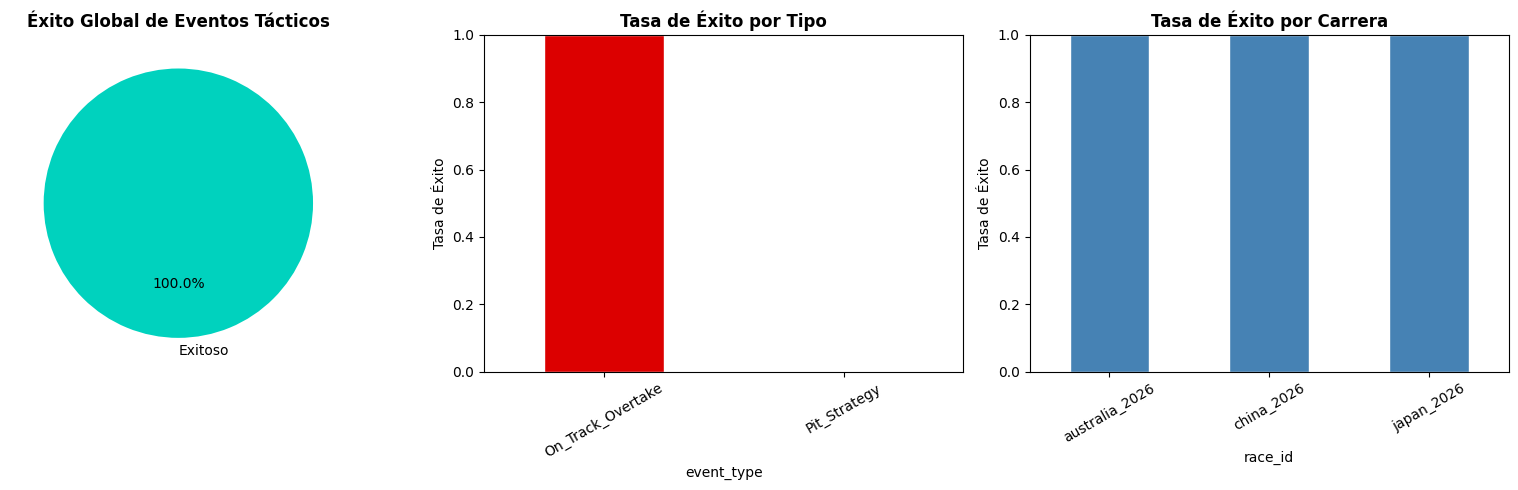

In [25]:
# Distribución de éxito en el nuevo dataset
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Éxito global
# Ensure both 0 (Fallido) and 1 (Exitoso) are present, even if count is 0
success_counts_display = tactical_events['success'].value_counts().reindex([0.0, 1.0], fill_value=0)

labels_display = []
colors_display = []
values_display = []

if success_counts_display.get(0.0, 0) > 0:
    labels_display.append('Fallido')
    colors_display.append(FERRARI_RED)
    values_display.append(success_counts_display[0.0])
if success_counts_display.get(1.0, 0) > 0:
    labels_display.append('Exitoso')
    colors_display.append(HAMILTON_CYAN)
    values_display.append(success_counts_display[1.0])

# Only plot if there's data to display
if len(values_display) > 0:
    axes[0].pie(values_display,
                labels=labels_display,
                colors=colors_display,
                autopct='%1.1f%%', startangle=90)
    axes[0].set_title('Éxito Global de Eventos Tácticos', fontweight='bold')
else:
    axes[0].set_title('No hay datos de éxito para mostrar', fontweight='bold')
    axes[0].text(0, 0, 'No data', horizontalalignment='center', verticalalignment='center', fontsize=12)

# Plot 2: Éxito por tipo de evento
tactical_events.groupby('event_type')['success'].mean().plot(
    kind='bar', ax=axes[1], color=[FERRARI_RED, HAMILTON_CYAN], edgecolor='white'
)
axes[1].set_title('Tasa de Éxito por Tipo', fontweight='bold')
axes[1].set_ylabel('Tasa de Éxito')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=30)

# Plot 3: Éxito por carrera
tactical_events.groupby('race_id')['success'].mean().plot(
    kind='bar', ax=axes[2], color='steelblue', edgecolor='white'
)
axes[2].set_title('Tasa de Éxito por Carrera', fontweight='bold')
axes[2].set_ylabel('Tasa de Éxito')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../artifacts/exito_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELDA 8 — Guardar `tactical_events_master.parquet`

Este es el archivo final que reemplaza a los 3 master parquets anteriores. Es la entrada para el PCA.

In [26]:
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../artifacts', exist_ok=True)

output_path = '../data/processed/tactical_events_master.parquet'
tactical_events.to_parquet(output_path, index=False)

file_size_kb = os.path.getsize(output_path) / 1024

print('✅ Archivo guardado exitosamente')
print(f'   Ruta: {output_path}')
print(f'   Tamaño: {file_size_kb:.1f} KB')
print(f'   Forma: {tactical_events.shape[0]} eventos × {tactical_events.shape[1]} variables')
print(f'\n📋 Columnas del dataset final:')
for i, col in enumerate(tactical_events.columns):
    print(f'   {i+1:3d}. {col}')

✅ Archivo guardado exitosamente
   Ruta: ../data/processed/tactical_events_master.parquet
   Tamaño: 300.9 KB
   Forma: 234 eventos × 185 variables

📋 Columnas del dataset final:
     1. race_id
     2. event_lap
     3. event_type
     4. event_type_binary
     5. attacker_driver
     6. defender_driver
     7. attacker_compound
     8. success
     9. attacker_compound_num
    10. att_position_at_event
    11. att_tyre_age_at_event
    12. att_is_pit_out
    13. att_stint_number
    14. att_pace_degradation
    15. def_position_at_event
    16. def_tyre_age_at_event
    17. def_compound_num
    18. def_stint_number
    19. def_pace_degradation
    20. delta_position
    21. delta_tyre_age
    22. delta_compound
    23. delta_degradation
    24. att_pit_duration
    25. att_had_recent_pit
    26. laps_since_att_pit
    27. def_pit_duration
    28. def_had_recent_pit
    29. laps_since_def_pit
    30. delta_pit_duration
    31. att_lap_duration_mean
    32. att_lap_duration_max
    33.

---
## CELDA 9 — Preparación para ML: Limpieza y Normalización

El PCA requiere:
1. Solo columnas numéricas
2. Sin valores nulos (imputamos con la media)
3. Variables estandarizadas (media=0, std=1)

In [27]:
# Columnas de metadata (no entran al PCA)
META_COLS = ['race_id', 'event_type', 'attacker_driver', 'defender_driver',
             'attacker_compound', 'success']

# Seleccionar solo columnas numéricas
numeric_cols = tactical_events.select_dtypes(include=[np.number]).columns.tolist()
# Excluir el target (success) y variables que son categorías codificadas de identificación
feature_cols = [c for c in numeric_cols if c not in ['success']]

print(f'Total variables numéricas para PCA: {len(feature_cols)}')

# Imputar valores nulos con la media de cada columna
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(tactical_events[feature_cols])

# Estandarizar (fundamental para PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Target vector
y = tactical_events['success'].fillna(0).astype(int).values

print(f'Matrix X escalada: {X_scaled.shape}')
print(f'Vector y (éxito):  {y.shape} — distribución: {np.bincount(y)}')

# Verificar NaN remanentes
print(f'NaN en X_scaled: {np.isnan(X_scaled).sum()}')

Total variables numéricas para PCA: 181
Matrix X escalada: (234, 181)
Vector y (éxito):  (234,) — distribución: [ 38 196]
NaN en X_scaled: 0


---
## CELDA 10 — PCA: Varianza Explicada

Primero determinamos cuántos componentes necesitamos para explicar el 80% y 95% de la varianza.

Componentes para 80% de varianza explicada: 21
Componentes para 90% de varianza explicada: 34
Componentes para 95% de varianza explicada: 47

PC1 explica: 15.9% de la varianza
PC2 explica: 7.8% de la varianza


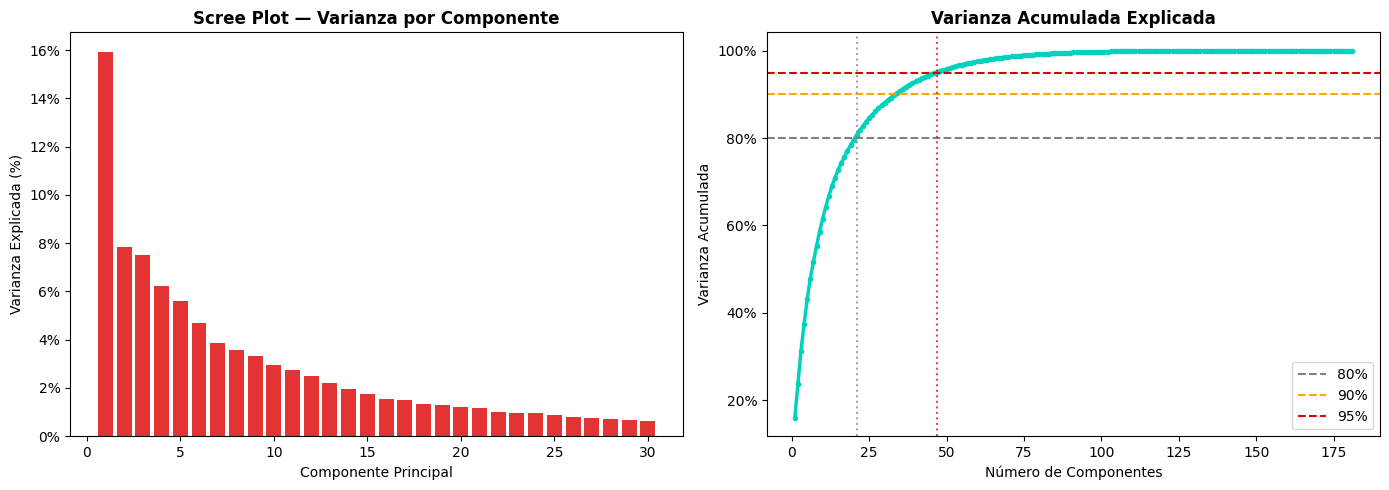

In [28]:
# PCA completo para análisis de varianza
pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Encontrar cuántos componentes se necesitan
n_80 = np.argmax(cumulative_var >= 0.80) + 1
n_90 = np.argmax(cumulative_var >= 0.90) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1

print(f'Componentes para 80% de varianza explicada: {n_80}')
print(f'Componentes para 90% de varianza explicada: {n_90}')
print(f'Componentes para 95% de varianza explicada: {n_95}')
print(f'\nPC1 explica: {explained_var[0]:.1%} de la varianza')
print(f'PC2 explica: {explained_var[1]:.1%} de la varianza')

# --- Gráfico Scree Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (varianza individual)
n_show = min(30, len(explained_var))
axes[0].bar(range(1, n_show+1), explained_var[:n_show], color=FERRARI_RED, alpha=0.8)
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Scree Plot — Varianza por Componente', fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Varianza acumulada
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var,
             color=HAMILTON_CYAN, linewidth=2.5, marker='o', markersize=3)
axes[1].axhline(y=0.80, color='gray', linestyle='--', label='80%')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90%')
axes[1].axhline(y=0.95, color=FERRARI_RED, linestyle='--', label='95%')
axes[1].axvline(x=n_80, color='gray', linestyle=':', alpha=0.7)
axes[1].axvline(x=n_95, color=FERRARI_RED, linestyle=':', alpha=0.7)
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada')
axes[1].set_title('Varianza Acumulada Explicada', fontweight='bold')
axes[1].legend()
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig('../artifacts/pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELDA 11 — PCA Reducido + Visualización 2D

Aplicamos PCA con los componentes que explican el 90% de la varianza y visualizamos los eventos en el espacio de PC1 vs PC2 coloreados por **éxito**.

PCA aplicado con 34 componentes
Dimensión reducida: (234, 34)


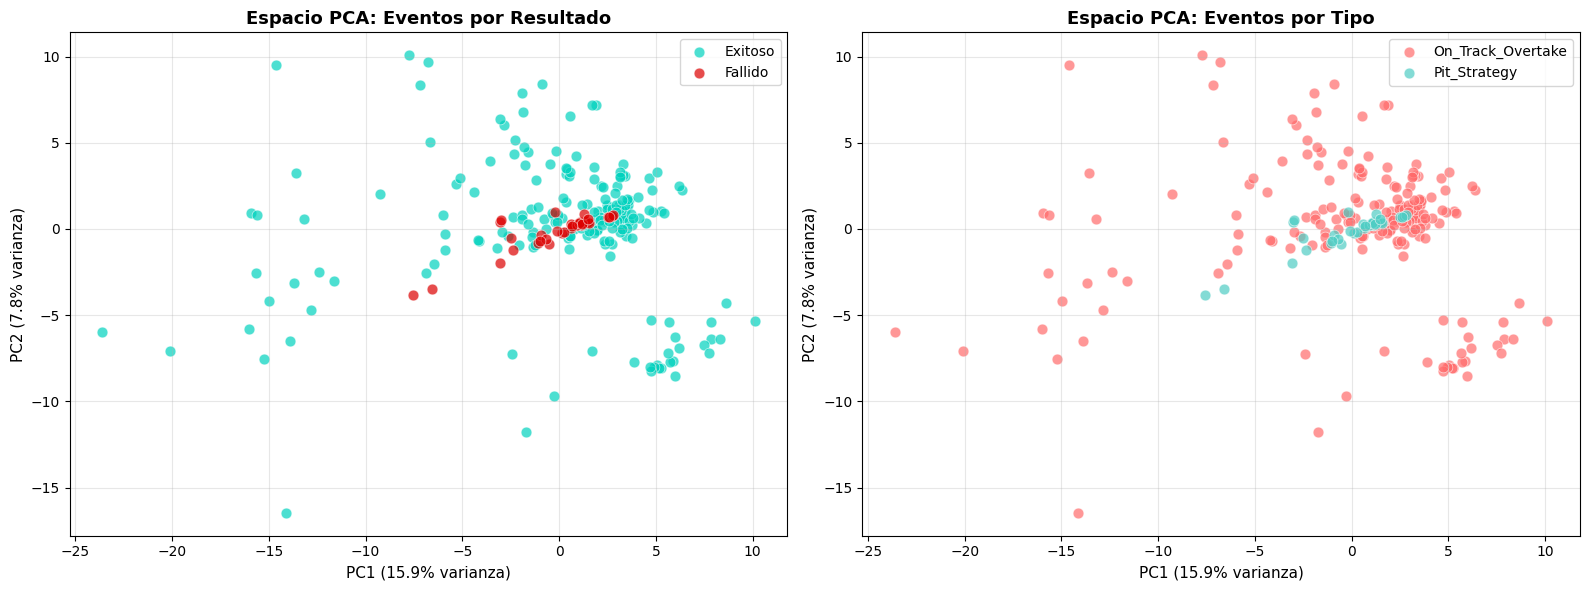

In [29]:
# PCA con n_90 componentes
N_COMPONENTS = n_90
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'PCA aplicado con {N_COMPONENTS} componentes')
print(f'Dimensión reducida: {X_pca.shape}')

# --- Scatter Plot PC1 vs PC2 coloreado por éxito ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Éxito (0 vs 1)
mask_success = y == 1
mask_fail    = y == 0

axes[0].scatter(X_pca[mask_success, 0], X_pca[mask_success, 1],
                c=HAMILTON_CYAN, label='Exitoso', alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
axes[0].scatter(X_pca[mask_fail, 0], X_pca[mask_fail, 1],
                c=FERRARI_RED, label='Fallido', alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=11)
axes[0].set_title('Espacio PCA: Eventos por Resultado', fontweight='bold', fontsize=13)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Coloreado por tipo de evento
event_types = tactical_events['event_type'].values
type_colors = {t: c for t, c in zip(np.unique(event_types), ['#FF6B6B', '#4ECDC4'])}
for etype, color in type_colors.items():
    mask = event_types == etype
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=etype, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=11)
axes[1].set_title('Espacio PCA: Eventos por Tipo', fontweight='bold', fontsize=13)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELDA 12 — Top Variables más Influyentes (Loadings de PC1 y PC2)

¿Qué variables tiene más 'peso' en cada componente principal? Esto nos dice **qué factores diferencian más** los eventos.

In [30]:
# Loadings = contribución de cada variable a cada componente principal
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

# Top 15 variables con mayor peso en PC1
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(15)
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(15)

print('=== TOP 15 VARIABLES MÁS INFLUYENTES EN PC1 ===')
for var, val in top_pc1.items():
    direction = '↑' if loadings.loc[var, 'PC1'] > 0 else '↓'
    print(f'  {direction} {var:<45} {val:.4f}')

print('\n=== TOP 15 VARIABLES MÁS INFLUYENTES EN PC2 ===')
for var, val in top_pc2.items():
    direction = '↑' if loadings.loc[var, 'PC2'] > 0 else '↓'
    print(f'  {direction} {var:<45} {val:.4f}')

=== TOP 15 VARIABLES MÁS INFLUYENTES EN PC1 ===
  ↑ def_st_speed_min                              0.1531
  ↑ def_i2_speed_mean                             0.1514
  ↓ def_i2_speed_std                              0.1489
  ↑ def_i2_speed_min                              0.1474
  ↑ att_st_speed_min                              0.1467
  ↓ def_st_speed_std                              0.1459
  ↓ att_st_speed_std                              0.1427
  ↑ att_i2_speed_mean                             0.1424
  ↑ att_i2_speed_min                              0.1404
  ↓ att_i2_speed_std                              0.1403
  ↓ def_duration_sector_1_mean                    0.1384
  ↑ def_i1_speed_min                              0.1355
  ↑ att_i1_speed_min                              0.1349
  ↓ def_lap_duration_mean                         0.1326
  ↑ att_st_speed_mean                             0.1325

=== TOP 15 VARIABLES MÁS INFLUYENTES EN PC2 ===
  ↑ def_duration_sector_2_Tminus1               

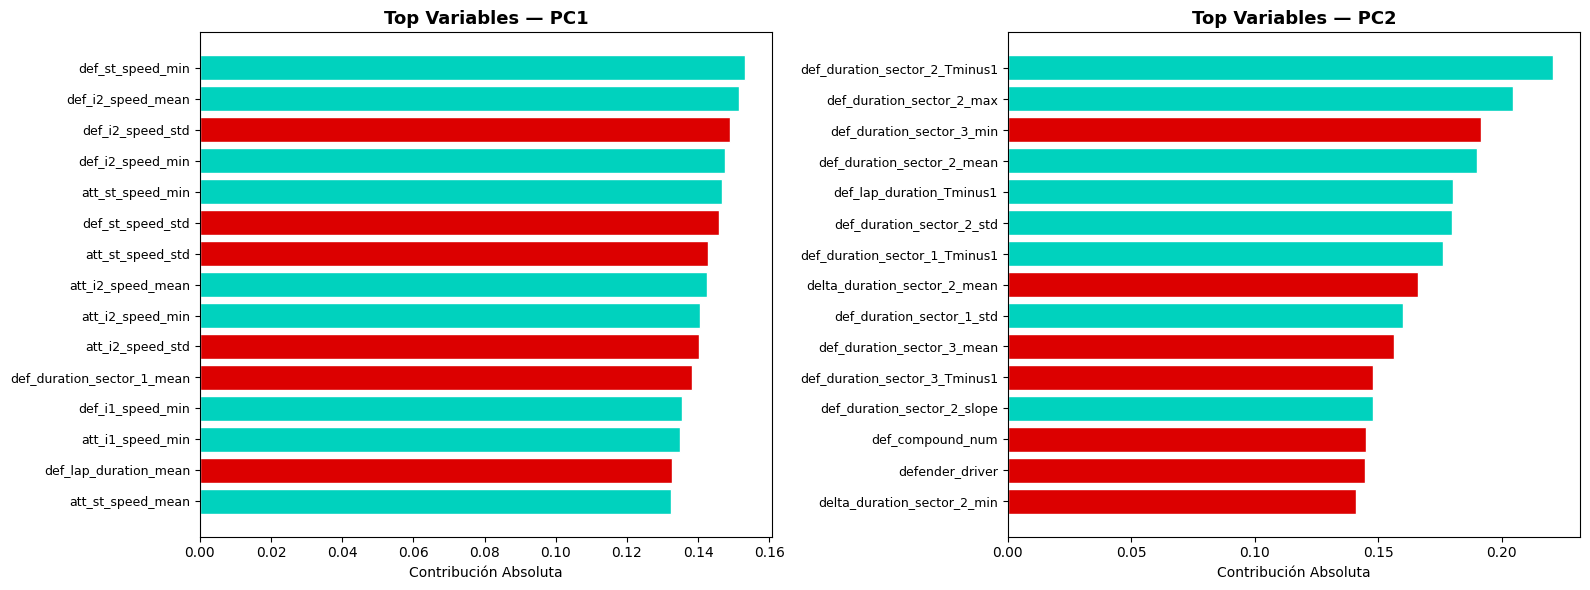

In [31]:
# Visualización de loadings
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (pc_name, top_vars) in zip(axes, [('PC1', top_pc1), ('PC2', top_pc2)]):
    colors = [FERRARI_RED if loadings.loc[v, pc_name] < 0 else HAMILTON_CYAN
              for v in top_vars.index]
    ax.barh(top_vars.index[::-1], top_vars.values[::-1], color=colors[::-1], edgecolor='white')
    ax.set_title(f'Top Variables — {pc_name}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Contribución Absoluta')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('../artifacts/pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELDA 13 — Clustering K-Means en el Espacio PCA

Aplicamos K-Means para encontrar **arquetipos de eventos tácticos** automáticamente.
Usaremos el método del codo para encontrar el K óptimo.

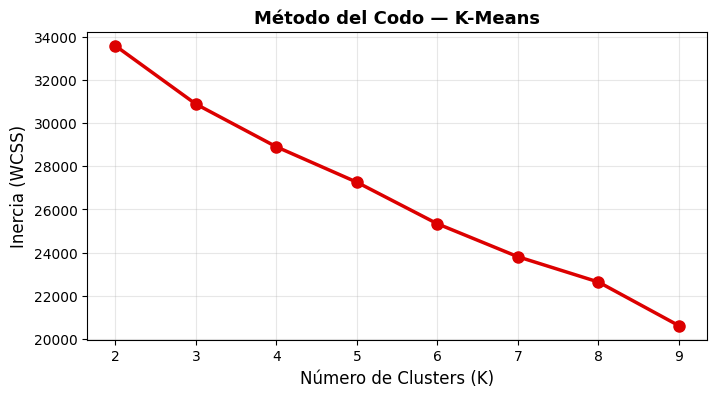

Observa el gráfico y elige el K donde la inercia deja de bajar bruscamente ("el codo")


In [32]:
# Método del codo para K óptimo
inertias = []
K_range = range(2, min(10, len(tactical_events)//5))

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, color=FERRARI_RED, linewidth=2.5, marker='o', markersize=8)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inercia (WCSS)', fontsize=12)
plt.title('Método del Codo — K-Means', fontweight='bold', fontsize=13)
plt.grid(alpha=0.3)
plt.savefig('../artifacts/kmeans_codo.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observa el gráfico y elige el K donde la inercia deja de bajar bruscamente ("el codo")')

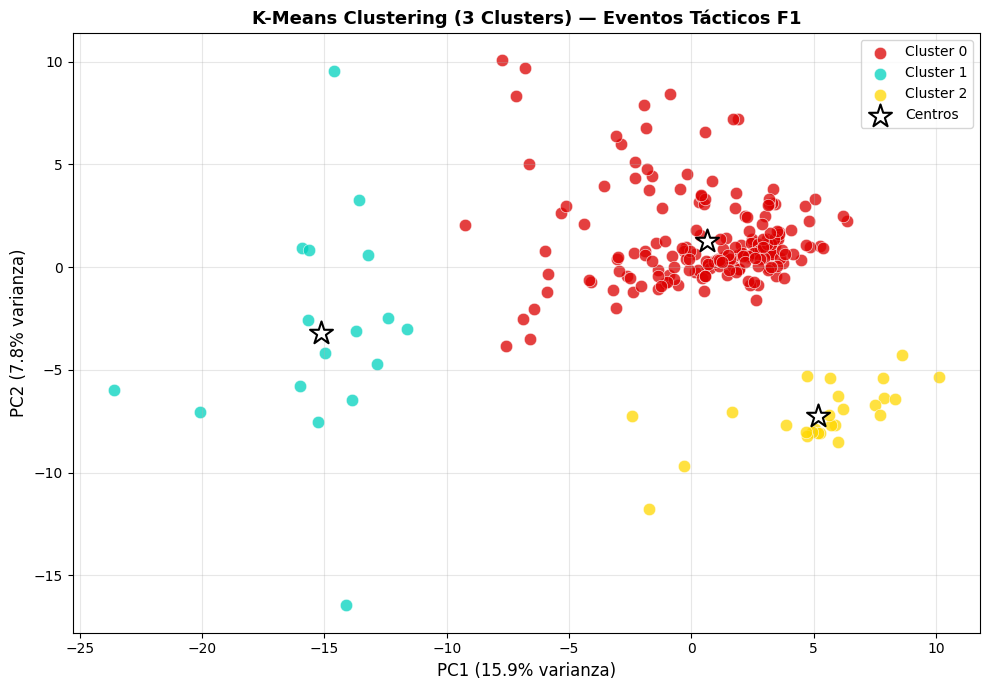

In [33]:
# Aplicar K-Means con K elegido (ajusta este valor según el gráfico del codo)
K_OPTIMAL = 3  # <--- CAMBIA ESTE VALOR según lo que veas en el gráfico de arriba

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# Agregar cluster al dataset
tactical_events['cluster'] = clusters

# --- Visualizar clusters en espacio PC1 vs PC2 ---
fig, ax = plt.subplots(figsize=(10, 7))
palette = [FERRARI_RED, HAMILTON_CYAN, '#FFD700', '#9B59B6', '#E67E22']

for cluster_id in range(K_OPTIMAL):
    mask = clusters == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=palette[cluster_id % len(palette)],
        label=f'Cluster {cluster_id}',
        alpha=0.75, s=80, edgecolors='white', linewidth=0.5
    )

# Centros de clusters
centers_2d = pca.transform(scaler.transform(imputer.transform(
    pd.DataFrame(scaler.inverse_transform(imputer.transform(
        np.zeros((K_OPTIMAL, len(feature_cols)))
    )), columns=feature_cols)
)))
# Versión simplificada: centros directamente en espacio PCA
centers = kmeans.cluster_centers_[:, :2]
ax.scatter(centers[:, 0], centers[:, 1], c='white', marker='*', s=300,
           edgecolors='black', linewidth=1.5, zorder=5, label='Centros')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=12)
ax.set_title(f'K-Means Clustering ({K_OPTIMAL} Clusters) — Eventos Tácticos F1',
             fontweight='bold', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELDA 14 — Caracterizar los Clusters (¿Qué describe cada arquetipo?)

In [34]:
# Perfil de cada cluster con variables clave
key_vars = [
    'success', 'event_type_binary', 'att_tyre_age_at_event', 'def_tyre_age_at_event',
    'delta_tyre_age', 'att_pace_degradation', 'def_pace_degradation',
    'att_lap_duration_mean', 'def_lap_duration_mean', 'delta_lap_duration_mean',
    'att_had_recent_pit', 'att_position_at_event', 'def_position_at_event',
    'delta_best_lap'
]
available_key_vars = [v for v in key_vars if v in tactical_events.columns]

cluster_profile = tactical_events.groupby('cluster')[available_key_vars].mean().round(3)

print('=== PERFIL PROMEDIO DE CADA CLUSTER ===')
display(cluster_profile.T)

print('\n=== TAMAÑO Y TASA DE ÉXITO POR CLUSTER ===')
cluster_summary = tactical_events.groupby('cluster').agg(
    n_eventos=('success', 'count'),
    tasa_exito=('success', 'mean'),
    tipo_dominante=('event_type', lambda x: x.value_counts().index[0])
).round(3)
display(cluster_summary)

=== PERFIL PROMEDIO DE CADA CLUSTER ===


cluster,0,1,2
success,1.000,1.000,1.000
event_type_binary,0.199,0.000,0.000
att_tyre_age_at_event,3.424,2.059,4.038
def_tyre_age_at_event,4.039,3.529,11.346
delta_tyre_age,-0.993,-1.471,-7.308
att_pace_degradation,3.780,0.987,0.209
def_pace_degradation,0.164,-5.401,-0.721
att_lap_duration_mean,98.374,111.424,93.487
def_lap_duration_mean,96.266,130.530,86.854
delta_lap_duration_mean,-0.396,-19.080,6.829



=== TAMAÑO Y TASA DE ÉXITO POR CLUSTER ===


,n_eventos,tasa_exito,tipo_dominante
cluster,,,
0,153,1.000,On_Track_Overtake
1,17,1.000,On_Track_Overtake
2,26,1.000,On_Track_Overtake


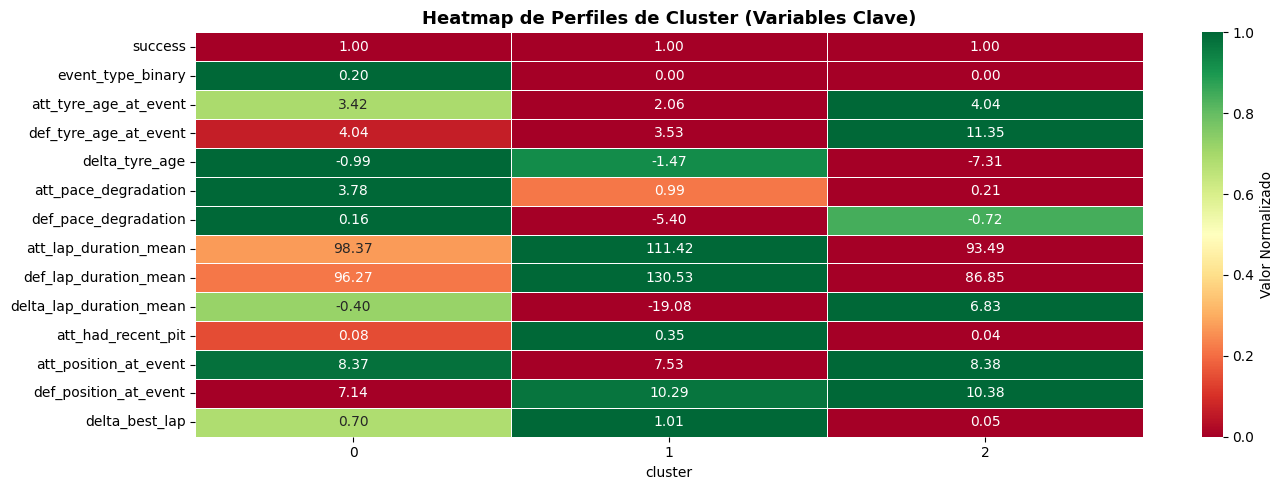

In [35]:
# Heatmap del perfil de clusters
numeric_profile = cluster_profile.select_dtypes(include=[np.number])

if len(numeric_profile.columns) > 0:
    # Normalizar para visualización
    profile_norm = (numeric_profile - numeric_profile.min()) / (numeric_profile.max() - numeric_profile.min() + 1e-9)

    plt.figure(figsize=(14, 5))
    sns.heatmap(
        profile_norm.T,
        annot=numeric_profile.T.round(2),
        cmap='RdYlGn',
        fmt='.2f',
        linewidths=0.5,
        cbar_kws={'label': 'Valor Normalizado'}
    )
    plt.title('Heatmap de Perfiles de Cluster (Variables Clave)', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('../artifacts/clusters_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## CELDA 15 — Guardar Dataset Final con Clusters

Guardamos la versión enriquecida con los clusters asignados.

In [36]:
final_path = '../data/processed/tactical_events_master.parquet'
tactical_events.to_parquet(final_path, index=False)

# También guardamos un CSV para revisión rápida
csv_path = '../data/processed/tactical_events_master.csv'
tactical_events.to_csv(csv_path, index=False)

print('✅ Dataset final guardado (con clusters):')
print(f'   Parquet: {final_path}')
print(f'   CSV:     {csv_path}')
print(f'   Forma final: {tactical_events.shape}')
print(f'   Variables totales: {tactical_events.shape[1]}')
print()
print('📋 Resumen del pipeline completado:')
print(f'   ✅ Eventos procesados:     {len(tactical_events)}')
print(f'   ✅ Variables generadas:    {tactical_events.shape[1]}')
print(f'   ✅ Componentes PCA (90%):  {N_COMPONENTS}')
print(f'   ✅ Clusters K-Means:       {K_OPTIMAL}')
print(f'   ✅ Archivos de gráficas:   ../artifacts/')

✅ Dataset final guardado (con clusters):
   Parquet: ../data/processed/tactical_events_master.parquet
   CSV:     ../data/processed/tactical_events_master.csv
   Forma final: (234, 186)
   Variables totales: 186

📋 Resumen del pipeline completado:
   ✅ Eventos procesados:     234
   ✅ Variables generadas:    186
   ✅ Componentes PCA (90%):  34
   ✅ Clusters K-Means:       3
   ✅ Archivos de gráficas:   ../artifacts/


---
## 📊 Resumen Final del Proyecto

### ¿Qué logramos?

| Etapa | Descripción | Resultado |
|-------|-------------|----------|
| **Carga** | 3 carreras × (master + events) | ~2,300 filas de telemetría, ~234 eventos |
| **Feature Engineering** | 7 sensores × 5 stats × 3 vueltas × 2 pilotos + deltas + contexto | ~120+ variables por evento |
| **PCA** | Reducción dimensional | 90% varianza en N componentes |
| **Clustering** | K-Means en espacio PCA | 3 arquetipos de eventos |

### Próximos pasos sugeridos:
1. **Ampliar sensores**: Si consigues car_data con speed/throttle/brake/rpm, agrégalos como sensores adicionales → llegas a 500+ variables
2. **Modelo predictivo**: Entrena un clasificador (Random Forest, XGBoost) con X_scaled e y para predecir éxito
3. **Más carreras**: Agrega Bahrain, Saudi Arabia, Miami para más eventos y mayor potencia estadística
4. **Análisis de Ferrari**: Filtra `att_is_ferrari_driver==1` para análisis específico de Leclerc/Hamilton